# Support Vector Machine — Classificação do Estado do Tabuleiro

Mesma estratégia de `GridSearchCV` do notebook de Random Forest, substituindo o modelo pelo **SVM**.

---
### Como funciona o SVM
O SVM encontra o **hiperplano de margem máxima** que separa as classes no espaço de features. Para dados não-linearmente separáveis, o **kernel trick** projeta implicitamente os dados em um espaço de maior dimensão onde a separação linear é possível — sem calcular explicitamente essa projeção.

No modo multiclasse, é usado o esquema **One-vs-Rest (OvR)**: um classificador binário por classe, e a classe com maior score de decisão vence.

### Por que o StandardScaler é necessário
O SVM é altamente sensível à escala das features: a margem e o kernel RBF dependem de distâncias euclidianas. Features em escalas diferentes distorcem essas distâncias e penalizam injustamente alguns pesos. O `StandardScaler` é encapsulado no `Pipeline` para que o `.pkl` seja autossuficiente.


## 1. Imports e Carregamento dos Splits


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

# X não é escalado aqui — o Pipeline aplica o StandardScaler internamente.
X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

le = LabelEncoder().fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")
print(f"\nClasses: {list(le.classes_)}")


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras

Classes: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']


## 2. Busca de Hiperparâmetros (GridSearchCV no Treino)


In [2]:
# Prefixo "svc__" direciona os parâmetros ao passo SVC dentro do Pipeline.
param_grid = {
    'svc__C':            [0.1, 1, 10, 100],
    'svc__kernel':       ['rbf', 'linear'],
    'svc__gamma':        ['scale', 'auto'],
    'svc__class_weight': ['balanced', None],
}

pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(random_state=42, decision_function_shape='ovr')),
])

grid_search = GridSearchCV(
    estimator=pipeline_base, param_grid=param_grid,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1,
)

print("Iniciando GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nMelhores parâmetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1 (CV): {grid_search.best_score_:.4f}")


Iniciando GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Melhores parâmetros encontrados:
  svc__C: 100
  svc__class_weight: balanced
  svc__gamma: scale
  svc__kernel: rbf

Melhor F1 (CV): 0.9549


## 3. Treinamento do Modelo Final


In [3]:
svm_model = grid_search.best_estimator_
svm_model.fit(X_train, y_train)
print("SVM final treinado.")


SVM final treinado.


## 4. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

      Empate       0.50      0.20      0.29         5
    O venceu       0.96      1.00      0.98        48
    Tem jogo       0.96      0.97      0.96        94
    X venceu       1.00      1.00      1.00        94

    accuracy                           0.97       241
   macro avg       0.85      0.79      0.81       241
weighted avg       0.97      0.97      0.97       241

Acurácia no Treino:    1.0000
Acurácia na Validação: 0.9710

✅  Diferença treino/validação dentro do esperado.


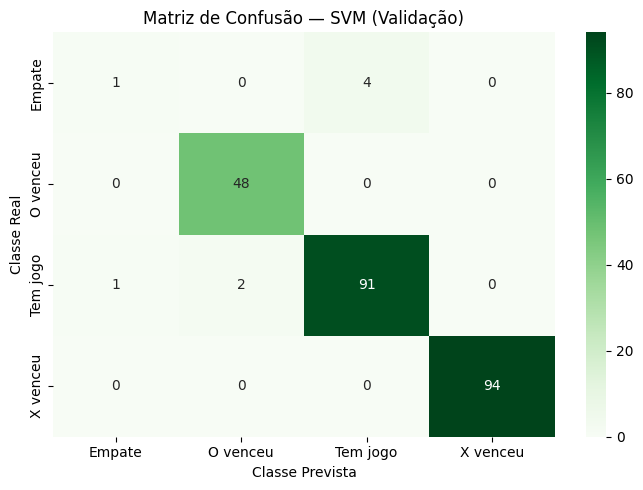

In [4]:
y_val_pred = svm_model.predict(X_val)

print("=== VALIDAÇÃO ===")
print(classification_report(
    le.inverse_transform(y_val),
    le.inverse_transform(y_val_pred),
    zero_division=0,
))

acc_treino = svm_model.score(X_train, y_train)
acc_val    = svm_model.score(X_val,   y_val)
print(f"Acurácia no Treino:    {acc_treino:.4f}")
print(f"Acurácia na Validação: {acc_val:.4f}")
if acc_treino - acc_val > 0.05:
    print("\n⚠️  Diferença > 5pp entre treino e validação — possível overfitting.")
else:
    print("\n✅  Diferença treino/validação dentro do esperado.")

plt.figure(figsize=(7, 5))
cm_val = confusion_matrix(le.inverse_transform(y_val), le.inverse_transform(y_val_pred), labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — SVM (Validação)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 5. Avaliação Final no Conjunto de Teste


=== TESTE ===
              precision    recall  f1-score   support

      Empate       0.50      0.60      0.55         5
    O venceu       1.00      1.00      1.00        47
    Tem jogo       0.98      0.96      0.97        94
    X venceu       0.99      1.00      0.99        94

    accuracy                           0.97       240
   macro avg       0.87      0.89      0.88       240
weighted avg       0.98      0.97      0.98       240

Acurácia no Teste: 0.9750


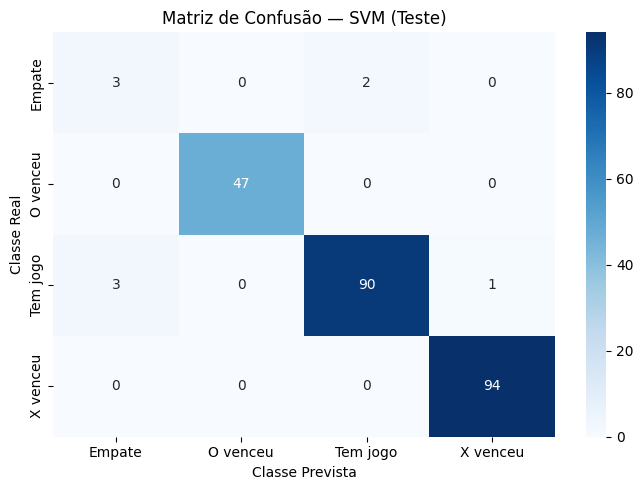

In [5]:
y_test_pred = svm_model.predict(X_test)

print("=== TESTE ===")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_test_pred),
    zero_division=0,
))

acc_teste = svm_model.score(X_test, y_test)
print(f"Acurácia no Teste: {acc_teste:.4f}")

plt.figure(figsize=(7, 5))
cm_test = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_test_pred), labels=le.classes_)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — SVM (Teste)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 6. Vetores de Suporte por Classe


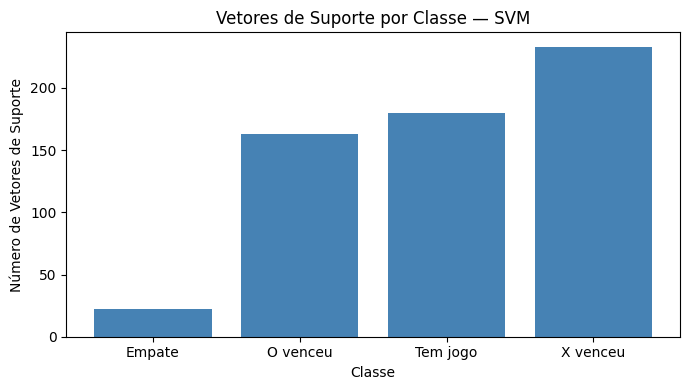

Total de vetores de suporte: 598
  Empate: 22
  O venceu: 163
  Tem jogo: 180
  X venceu: 233


In [7]:
svc_step = svm_model.named_steps['svc']
sv_counts = dict(zip(le.classes_, svc_step.n_support_))

plt.figure(figsize=(7, 4))
plt.bar(sv_counts.keys(), sv_counts.values(), color='steelblue')
plt.title('Vetores de Suporte por Classe — SVM')
plt.xlabel('Classe'); plt.ylabel('Número de Vetores de Suporte')
plt.tight_layout(); plt.show()

print(f"Total de vetores de suporte: {svc_step.n_support_.sum()}")
for classe, n in sv_counts.items():
    print(f"  {classe}: {n}")


## 7. Persistência do Modelo


In [6]:
os.makedirs('../../models/SVM', exist_ok=True)
joblib.dump(svm_model, '../../models/SVM/svm_model.pkl')
joblib.dump(le,        '../../models/SVM/svm_label_encoder.pkl')
print("Modelo (Pipeline) e Encoder salvos com sucesso!")


Modelo (Pipeline) e Encoder salvos com sucesso!
